## Import Library

In [1]:
import re
import warnings
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from scipy.sparse import csr_matrix
from sklearn.preprocessing import normalize
from tqdm import tqdm

from gensim.models import Word2Vec
from gensim.models.phrases import Phrases, Phraser

from nltk import pos_tag, word_tokenize
from nltk.corpus import stopwords, wordnet
from nltk.stem import WordNetLemmatizer

warnings.filterwarnings('ignore')
matplotlib.rcParams.update({'font.size': 13})

## Konfigurasi

In [2]:
# Parameter eksperimen — sama persis dengan item-based v6 agar hasil comparable
K_LIST     = [3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
ALPHA_LIST = [round(a * 0.1, 1) for a in range(11)]

RANDOM_SEED = 42
TEXT_COL    = 'review_text'
RATING_MIN  = 1.0
RATING_MAX  = 5.0

SIGNIFICANCE_GAMMA = 10

print(f"K_LIST              : {K_LIST}")
print(f"ALPHA_LIST          : {ALPHA_LIST}")
print(f"Rating clip         : [{RATING_MIN}, {RATING_MAX}]")
print(f"SIGNIFICANCE_GAMMA  : {SIGNIFICANCE_GAMMA}")
print(f"Total kombinasi     : {len(K_LIST) * len(ALPHA_LIST)}  (K × Alpha)")

K_LIST              : [3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
ALPHA_LIST          : [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
Rating clip         : [1.0, 5.0]
SIGNIFICANCE_GAMMA  : 10
Total kombinasi     : 110  (K × Alpha)


## Load & Preprocessing Data

In [3]:
Rating = pd.read_csv('../Percobaan/dataset/rating/TA13.csv')
Rating.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 80122 entries, 0 to 80121
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   offering_id    80122 non-null  int64  
 1   user_id        80122 non-null  object 
 2   overall        80122 non-null  float64
 3   value          72861 non-null  float64
 4   service        72494 non-null  float64
 5   location       64545 non-null  float64
 6   rooms          67724 non-null  float64
 7   cleanliness    72979 non-null  float64
 8   sleep_quality  45586 non-null  float64
 9   review_text    80122 non-null  object 
dtypes: float64(7), int64(1), object(2)
memory usage: 6.1+ MB


In [4]:
Rating.rename(columns={'offering_id': 'hotel_id', 'overall': 'rating'}, inplace=True)

Dataset = (
    Rating[['user_id', 'hotel_id', 'rating']]
    .dropna(subset=['rating'])
    .reset_index(drop=True)
    .copy()
)

print(f"Total baris  : {len(Dataset):,}")
print(f"Total hotel  : {Dataset['hotel_id'].nunique():,}")
print(f"Total user   : {Dataset['user_id'].nunique():,}")
print(f"Range rating : {Dataset['rating'].min()} – {Dataset['rating'].max()}")

Total baris  : 80,122
Total hotel  : 3,145
Total user   : 11,398
Range rating : 1.0 – 5.0


In [5]:
Dataset.isnull().sum()

user_id     0
hotel_id    0
rating      0
dtype: int64

In [6]:
# Rata-rata hotel yang dirating per user
hotel_per_user = Rating.groupby('user_id')['hotel_id'].nunique()

# Rata-rata user yang memberi rating per hotel
user_per_hotel = Rating.groupby('hotel_id')['user_id'].nunique()

print(f"Rata-rata hotel per user  : {hotel_per_user.mean():.2f}")
print(f"Rata-rata user per hotel  : {user_per_hotel.mean():.2f}")

Rata-rata hotel per user  : 7.03
Rata-rata user per hotel  : 25.48


In [7]:
# Jumlah user unik
n_users = Rating['user_id'].nunique()

# Jumlah hotel unik
n_hotels = Rating['hotel_id'].nunique()

# Jumlah rating yang ada
n_ratings = len(Rating)

# Density
density = n_ratings / (n_users * n_hotels)

print(f"Jumlah User    : {n_users}")
print(f"Jumlah Hotel   : {n_hotels}")
print(f"Jumlah Rating  : {n_ratings}")
print(f"Density        : {density:.4f}")
print(f"Density (%)    : {density*100:.2f}%")

Jumlah User    : 11398
Jumlah Hotel   : 3145
Jumlah Rating  : 80122
Density        : 0.0022
Density (%)    : 0.22%


## Split Train / Test (80/20 Per User)

In [8]:
train_list, test_list = [], []

for uid, grp in Dataset.groupby('user_id', sort=False):
    grp     = grp.sample(frac=1, random_state=RANDOM_SEED).reset_index(drop=True)
    n_train = max(1, int(len(grp) * 0.8))
    train_list.append(grp.iloc[:n_train])
    if n_train < len(grp):
        test_list.append(grp.iloc[n_train:])

train_df = pd.concat(train_list, ignore_index=True).dropna(subset=['rating'])
test_df  = pd.concat(test_list,  ignore_index=True).dropna(subset=['rating'])

# Statistik referensi hanya dari train — cegah data leakage
global_mean = train_df['rating'].mean()

print(f"Train       : {len(train_df):,} baris")
print(f"Test        : {len(test_df):,}  baris")
print(f"Global mean : {global_mean:.4f}")

Train       : 60,231 baris
Test        : 19,891  baris
Global mean : 3.8964


## Bangun User-Based CF Matrix

In [9]:
# hotel_id ke str dulu untuk konsistensi key di semua dict
train_df = train_df.copy()
train_df['hotel_id'] = train_df['hotel_id'].astype(int).astype(str)
test_df  = test_df.copy()
test_df['hotel_id']  = test_df['hotel_id'].astype(int).astype(str)

# hotel_mean hanya dari train — dipakai untuk fallback cold-start
hotel_mean_rating = (
    train_df.groupby('hotel_id')['rating'].mean()
    .to_dict()
)

# setiap baris mewakili profil rating satu user
user_rating_matrix = train_df.pivot_table(
    index='user_id', columns='hotel_id', values='rating'
)


# menghilangkan bias skala rating tiap user (user yang selalu kasih nilai tinggi/rendah)
user_mean_row           = user_rating_matrix.mean(axis=1)
user_matrix_adjusted    = user_rating_matrix.sub(user_mean_row, axis='index')
user_matrix_adj_filled  = user_matrix_adjusted.fillna(0).astype(np.float32)

cf_user_ids     = list(user_rating_matrix.index)        
cf_user_to_idx  = {u: i for i, u in enumerate(cf_user_ids)}
cf_vectors      = user_matrix_adj_filled.values         
cf_vectors_norm = normalize(cf_vectors, axis=1)         

# Significance weighting: hitung jumlah hotel yang sama-sama di-rating tiap pasangan user
_rating_mask    = (~user_rating_matrix.isna()).astype(np.float32)
_mask_sparse    = csr_matrix(_rating_mask.values)
co_rated_counts = np.asarray((_mask_sparse @ _mask_sparse.T).todense())  # shape: (n_user, n_user)

print(f"User-rating matrix shape : {cf_vectors_norm.shape}  (user × hotel, adjusted cosine by user mean)")
print(f"Total user di train      : {len(cf_user_ids):,}")
print(f"Total hotel di train     : {user_rating_matrix.shape[1]:,}")
print(f"Median co-rated per pasangan user (>0): {np.median(co_rated_counts[co_rated_counts > 0]):.1f}")

User-rating matrix shape : (11398, 3007)  (user × hotel, adjusted cosine by user mean)
Total user di train      : 11,398
Total hotel di train     : 3,007
Median co-rated per pasangan user (>0): 1.0


In [10]:
n_ratings = user_rating_matrix.notna().sum().sum()
n_total   = user_rating_matrix.shape[0] * user_rating_matrix.shape[1]

density = n_ratings / n_total * 100

print(f"Shape matrix                : {user_rating_matrix.shape}  (user × hotel)")
print(f"Jumlah rating yang terisi   : {n_ratings:,}")
print(f"Total sel matrix            : {n_total:,}")
print(f"Densitas matrix             : {density:.4f}%")
print(f"Sparsity matrix             : {100 - density:.4f}%")

Shape matrix                : (11398, 3007)  (user × hotel)
Jumlah rating yang terisi   : 60,231
Total sel matrix            : 34,273,786
Densitas matrix             : 0.1757%
Sparsity matrix             : 99.8243%


## Bangun Vektor Hotel dengan Word2Vec (CBF)

In [11]:
STOP_WORDS = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

_POS_MAP = {'J': wordnet.ADJ, 'V': wordnet.VERB, 'N': wordnet.NOUN, 'R': wordnet.ADV}

def _get_wordnet_pos(word: str) -> str:
    tag = pos_tag([word])[0][1][0].upper()
    return _POS_MAP.get(tag, wordnet.NOUN)

def preprocess_text(text) -> list[str]:
    if pd.isnull(text) or not isinstance(text, (str, int, float)):
        return []
    text   = re.sub(r'[^a-zA-Z0-9,]', ' ', str(text))
    text   = re.sub(r'\s+', ' ', text).strip().lower()
    tokens = word_tokenize(text)
    tokens = [w for w in tokens if w not in STOP_WORDS and len(w) > 2]
    tokens = [lemmatizer.lemmatize(w, _get_wordnet_pos(w)) for w in tokens]
    return tokens

In [12]:
train_hotel_ids = set(train_df['hotel_id'].unique())
train_pairs     = set(zip(train_df['user_id'], train_df['hotel_id']))

rating_text = Rating[['user_id', 'hotel_id', TEXT_COL]].copy()
rating_text['hotel_id'] = rating_text['hotel_id'].astype(int).astype(str)
rating_text = rating_text[
    rating_text.apply(lambda r: (r['user_id'], r['hotel_id']) in train_pairs, axis=1)
]
rating_text['tokens'] = rating_text[TEXT_COL].apply(preprocess_text)

hotel_texts = (
    rating_text
    .groupby('hotel_id')['tokens']
    .apply(lambda x: [tok for sublist in x for tok in sublist])
    .reset_index()
)
hotel_texts = hotel_texts[hotel_texts['tokens'].map(len) > 0].copy()

print(f"Hotel dengan data teks : {len(hotel_texts):,}")

Hotel dengan data teks : 3,007


In [13]:
raw_sentences = [
    [str(w) for w in tokens]
    for tokens in hotel_texts['tokens']
    if isinstance(tokens, list) and len(tokens) > 0
]

bigram       = Phraser(Phrases(raw_sentences, min_count=3, threshold=8))
bi_sents     = [bigram[s] for s in raw_sentences]
trigram      = Phraser(Phrases(bi_sents, min_count=2, threshold=6))
all_sentences = [trigram[s] for s in bi_sents]

hotel_texts['tokens_final'] = all_sentences

print(f"Total dokumen hotel : {len(all_sentences)}")
print(f"Token unik          : {len(set(tok for s in all_sentences for tok in s)):,}")

Total dokumen hotel : 3007
Token unik          : 121,271


In [14]:
model_w2v = Word2Vec(
    sentences=all_sentences,
    workers=1, seed=RANDOM_SEED
)

print(f"Ukuran vocab   : {len(model_w2v.wv):,} kata")
print(f"Dimensi vektor : {model_w2v.vector_size}")

def _build_hotel_vector(tokens: list[str]) -> np.ndarray | None:
    vecs = [model_w2v.wv[t] for t in tokens if t in model_w2v.wv]
    return np.mean(vecs, axis=0) if vecs else None

hotel_vec_dict = {}
for _, row in hotel_texts.iterrows():
    vec = _build_hotel_vector(row['tokens_final'])
    if vec is not None:
        hotel_vec_dict[str(row['hotel_id'])] = vec

print(f"\nHotel dengan vektor : {len(hotel_vec_dict):,}")
print(f"Coverage            : {len(hotel_vec_dict) / len(train_hotel_ids) * 100:.1f}%")

Ukuran vocab   : 47,950 kata
Dimensi vektor : 100

Hotel dengan vektor : 3,007
Coverage            : 100.0%


## Bangun CBF Item Matrix & Profil Konten User (Pure CBF)


In [15]:
item_hotel_ids    = list(hotel_vec_dict.keys())
item_vectors      = np.array(list(hotel_vec_dict.values()), dtype=np.float32)
item_vectors_norm = normalize(item_vectors, axis=1)
item_hotel_to_idx = {h: i for i, h in enumerate(item_hotel_ids)}

print(f"CBF item matrix shape : {item_vectors_norm.shape}  (hotel × dim Word2Vec)")

CBF item matrix shape : (3007, 100)  (hotel × dim Word2Vec)


### Profil Konten User (untuk Pure CBF)


In [16]:


user_profile_raw = {}   # user_id (str) -> np.ndarray, vektor preferensi (belum dinormalisasi)

for uid, grp in train_df.groupby('user_id'):
    vecs, weights = [], []
    for hid, r in zip(grp['hotel_id'], grp['rating']):
        vec = hotel_vec_dict.get(str(hid))
        if vec is None:
            continue
        vecs.append(vec)
        weights.append(float(r) - global_mean)

    if len(vecs) == 0:
        continue   # user ini tidak punya hotel dengan vektor Word2Vec sama sekali

    vecs    = np.array(vecs, dtype=np.float32)
    weights = np.array(weights, dtype=np.float32)

    if np.abs(weights).sum() < 1e-8:
        profile = vecs.mean(axis=0)
    else:
        profile = (weights[:, None] * vecs).sum(axis=0) / np.abs(weights).sum()

    user_profile_raw[str(uid)] = profile

user_profile_ids        = list(user_profile_raw.keys())
user_profile_matrix     = np.array([user_profile_raw[u] for u in user_profile_ids], dtype=np.float32)
user_profile_matrix_norm = normalize(user_profile_matrix, axis=1)
user_profile_to_idx     = {u: i for i, u in enumerate(user_profile_ids)}

print(f"User dengan profil konten : {len(user_profile_ids):,} dari {train_df['user_id'].nunique():,} user di train")
print(f"Dimensi profil            : {user_profile_matrix_norm.shape[1]}  (sama dengan dimensi vektor Word2Vec hotel)")


User dengan profil konten : 11,398 dari 11,398 user di train
Dimensi profil            : 100  (sama dengan dimensi vektor Word2Vec hotel)


### Kalibrasi Similarity → Skala Rating


In [17]:
calib_sims, calib_ratings = [], []

for uid, grp in train_df.groupby('user_id'):
    vecs, weights, ratings = [], [], []
    for hid, r in zip(grp['hotel_id'], grp['rating']):
        vec = hotel_vec_dict.get(str(hid))
        if vec is None:
            continue
        vecs.append(vec)
        weights.append(float(r) - global_mean)
        ratings.append(float(r))

    if len(vecs) < 2:
        continue   # butuh minimal 2 hotel supaya leave-one-out bermakna

    vecs    = np.array(vecs, dtype=np.float32)
    weights = np.array(weights, dtype=np.float32)

    full_sum  = (weights[:, None] * vecs).sum(axis=0)
    full_absw = np.abs(weights).sum()

    for i in range(len(vecs)):
        loo_absw = full_absw - abs(weights[i])
        if loo_absw < 1e-8:
            # sisa bobot ~0 -> pakai rata-rata polos dari item selain i
            other = np.delete(vecs, i, axis=0)
            if len(other) == 0:
                continue
            loo_profile = other.mean(axis=0)
        else:
            loo_sum     = full_sum - weights[i] * vecs[i]
            loo_profile = loo_sum / loo_absw

        sim = float(
            normalize(loo_profile.reshape(1, -1))[0].dot(
                normalize(vecs[i].reshape(1, -1))[0]
            )
        )
        calib_sims.append(sim)
        calib_ratings.append(ratings[i])

calib_sims    = np.array(calib_sims, dtype=np.float64)
calib_ratings = np.array(calib_ratings, dtype=np.float64)

# Regresi linear: rating = a*sim + b  (least squares)
_A = np.vstack([calib_sims, np.ones_like(calib_sims)]).T
calib_a, calib_b = np.linalg.lstsq(_A, calib_ratings, rcond=None)[0]

print(f"Jumlah pasangan kalibrasi : {len(calib_sims):,}")
print(f"Kalibrasi CBF             : rating ≈ {calib_a:.4f} * sim + {calib_b:.4f}")
print(f"Range sim (train)         : [{calib_sims.min():.3f}, {calib_sims.max():.3f}]")


Jumlah pasangan kalibrasi : 60,231
Kalibrasi CBF             : rating ≈ 0.1717 * sim + 3.8829
Range sim (train)         : [-0.998, 0.999]


## Fungsi Prediksi

In [ ]:
# Collaborative Filtering - cari K user paling mirip

cf_neighbors_cache = {}

def _get_cf_similar_users(user_id, k: int) -> list[tuple]:
    uid = str(user_id)
    key = (uid, k)
    if key in cf_neighbors_cache:
        return cf_neighbors_cache[key]

    if uid not in cf_user_to_idx:
        cf_neighbors_cache[key] = []
        return []

    idx       = cf_user_to_idx[uid]
    query_vec = cf_vectors_norm[idx].reshape(1, -1)
    sims      = cf_vectors_norm.dot(query_vec.T).flatten()

    sig_weight = np.minimum(co_rated_counts[idx] / SIGNIFICANCE_GAMMA, 1.0)
    sims       = sims * sig_weight

    sims[idx] = -999.0   # exclude diri sendiri
    top_idxs  = np.argsort(sims)[::-1][:k]
    result    = [(cf_user_ids[i], float(sims[i])) for i in top_idxs if sims[i] > -999.0]

    cf_neighbors_cache[key] = result
    return result

def _fallback_rating(hotel_id: str) -> float:
    fb = hotel_mean_rating.get(str(hotel_id))
    if fb is not None and not np.isnan(fb):
        return float(np.clip(fb, RATING_MIN, RATING_MAX))
    return float(np.clip(global_mean, RATING_MIN, RATING_MAX))


# CF PREDICT
def predict_rating_knn(user_id, hotel_id: str, k: int):

    hotel_id = str(hotel_id)
    sim_users = _get_cf_similar_users(user_id, k)

    if not sim_users:
        return _fallback_rating(hotel_id), 'knn_cold_user'

    # rata-rata rating user aktif
    active_mean = user_rating_matrix.loc[str(user_id)].mean(skipna=True)

    score_num = 0.0
    score_den = 0.0

    for nb_uid, sim in sim_users:

        try:
            nb_rating = user_rating_matrix.loc[nb_uid, hotel_id]
        except KeyError:
            continue

        if pd.isnull(nb_rating):
            continue

        # rata-rata rating neighbor
        nb_mean = user_rating_matrix.loc[nb_uid].mean(skipna=True)

        score_num += sim * (float(nb_rating) - nb_mean)
        score_den += abs(sim)

    if score_den > 0:
        pred = active_mean + (score_num / score_den)
        pred = np.clip(pred, RATING_MIN, RATING_MAX)
        return float(pred), 'knn'

    return _fallback_rating(hotel_id), 'knn_fallback'


# CBF PREDICT (Pure CBF) 
def predict_rating_cbf(user_id, hotel_id: str, top_n: int = 24) -> tuple[float, str]:
    
    hotel_id = str(hotel_id)
    uid      = str(user_id)

    if uid not in user_profile_to_idx:
        return _fallback_rating(hotel_id), 'cbf_cold_user'

    if hotel_id not in item_hotel_to_idx:
        return _fallback_rating(hotel_id), 'cbf_no_vector'

    p_idx = user_profile_to_idx[uid]
    h_idx = item_hotel_to_idx[hotel_id]

    sim  = float(user_profile_matrix_norm[p_idx].dot(item_vectors_norm[h_idx]))
    pred = calib_a * sim + calib_b
    pred = float(np.clip(pred, RATING_MIN, RATING_MAX))

    return pred, 'cbf_pure'


# HYBRID PREDICT

def predict_rating_hybrid(user_id, hotel_id: str, k: int, alpha: float) -> tuple[float, str]:
    knn_pred, knn_strat = predict_rating_knn(user_id, hotel_id, k)
    cbf_pred, cbf_strat = predict_rating_cbf(user_id, hotel_id)

    pred = alpha * knn_pred + (1 - alpha) * cbf_pred

    knn_ok = knn_strat == 'knn'
    cbf_ok = cbf_strat == 'cbf_pure'
    if knn_ok and cbf_ok:
        strategy = f'hybrid(α={alpha:.1f})'
    elif knn_ok:
        strategy = f'hybrid(α={alpha:.1f})_cbf_fallback'
    elif cbf_ok:
        strategy = f'hybrid(α={alpha:.1f})_knn_fallback'
    else:
        strategy = f'hybrid(α={alpha:.1f})_both_fallback'

    return float(np.clip(pred, RATING_MIN, RATING_MAX)), strategy

## Precompute Neighbors Cache

In [19]:
# Menghitung neighbor seluruh user pada data uji sebelum grid search untuk menghindari perhitungan ulang similarity pada setiap kombinasi K dan α.

print("Precomputing neighbors...")
test_user_ids  = test_df['user_id'].unique().tolist()
test_hotel_ids = test_df['hotel_id'].astype(str).unique().tolist()

for k in tqdm(K_LIST, desc="Cache CF per K"):
    for uid in test_user_ids:
        _get_cf_similar_users(uid, k)

print(f"Cache siap — CF: {len(cf_neighbors_cache)} entries")

Precomputing neighbors...


Cache CF per K: 100%|██████████| 10/10 [10:59<00:00, 65.97s/it]

Cache siap — CF: 113980 entries


## Grid Search K × Alpha

In [20]:
grid_results = []

for k in K_LIST:
    for alpha in ALPHA_LIST:
        actuals, preds = [], []

        for _, row in test_df.iterrows():
            uid    = row['user_id']
            hid    = str(row['hotel_id'])
            actual = float(row['rating'])

            pred, _ = predict_rating_hybrid(uid, hid, k, alpha)
            actuals.append(actual)
            preds.append(pred)

        actuals_arr = np.array(actuals)
        preds_arr   = np.array(preds)
        rmse = float(np.sqrt(np.mean((preds_arr - actuals_arr) ** 2)))
        mae  = float(np.mean(np.abs(preds_arr - actuals_arr)))

        grid_results.append({'K': k, 'alpha': alpha, 'RMSE': rmse, 'MAE': mae})
        print(f"  K={k:>2}, α={alpha:.1f}  →  RMSE={rmse:.4f}  MAE={mae:.4f}")

df_grid = pd.DataFrame(grid_results)
print(f"\nGrid search selesai — {len(df_grid)} kombinasi")
print(df_grid.sort_values('RMSE').head(10).to_string(index=False))

  K= 3, α=0.0  →  RMSE=0.9630  MAE=0.7473
  K= 3, α=0.1  →  RMSE=0.9496  MAE=0.7344
  K= 3, α=0.2  →  RMSE=0.9384  MAE=0.7257
  K= 3, α=0.3  →  RMSE=0.9295  MAE=0.7187
  K= 3, α=0.4  →  RMSE=0.9230  MAE=0.7139
  K= 3, α=0.5  →  RMSE=0.9190  MAE=0.7117
  K= 3, α=0.6  →  RMSE=0.9174  MAE=0.7117
  K= 3, α=0.7  →  RMSE=0.9182  MAE=0.7133
  K= 3, α=0.8  →  RMSE=0.9216  MAE=0.7163
  K= 3, α=0.9  →  RMSE=0.9273  MAE=0.7204
  K= 3, α=1.0  →  RMSE=0.9355  MAE=0.7251
  K= 4, α=0.0  →  RMSE=0.9630  MAE=0.7473
  K= 4, α=0.1  →  RMSE=0.9496  MAE=0.7344
  K= 4, α=0.2  →  RMSE=0.9384  MAE=0.7259
  K= 4, α=0.3  →  RMSE=0.9296  MAE=0.7190
  K= 4, α=0.4  →  RMSE=0.9231  MAE=0.7143
  K= 4, α=0.5  →  RMSE=0.9192  MAE=0.7122
  K= 4, α=0.6  →  RMSE=0.9177  MAE=0.7122
  K= 4, α=0.7  →  RMSE=0.9187  MAE=0.7139
  K= 4, α=0.8  →  RMSE=0.9222  MAE=0.7171
  K= 4, α=0.9  →  RMSE=0.9282  MAE=0.7212
  K= 4, α=1.0  →  RMSE=0.9366  MAE=0.7260
  K= 5, α=0.0  →  RMSE=0.9630  MAE=0.7473
  K= 5, α=0.1  →  RMSE=0.9496  MAE

## Hasil Kombinasi Terbaik

In [21]:
best_row   = df_grid.loc[df_grid['RMSE'].idxmin()]
best_k     = int(best_row['K'])
best_alpha = float(best_row['alpha'])

pivot_rmse = df_grid.pivot(index='K', columns='alpha', values='RMSE')
pivot_mae  = df_grid.pivot(index='K', columns='alpha', values='MAE')

print("Kombinasi terbaik (RMSE minimum):")
print(f"   K     : {best_k}")
print(f"   Alpha : {best_alpha}  (KNN={best_alpha:.0%}, CBF={1-best_alpha:.0%})")
print(f"   RMSE  : {best_row['RMSE']:.4f}")
print(f"   MAE   : {best_row['MAE']:.4f}")

Kombinasi terbaik (RMSE minimum):
   K     : 3
   Alpha : 0.6  (KNN=60%, CBF=40%)
   RMSE  : 0.9174
   MAE   : 0.7117


## Evaluasi Detail KNN / CBF / Hybrid

In [22]:
def _rmse(p, a): return float(np.sqrt(np.mean((p - a) ** 2)))
def _mae(p, a):  return float(np.mean(np.abs(p - a)))

actuals_best    = []
preds_hybrid    = []
preds_knn_only  = []
preds_cbf_only  = []
strategies_best = []

for _, row in tqdm(test_df.iterrows(), total=len(test_df),
                   desc=f'Eval K={best_k} α={best_alpha}'):
    uid    = row['user_id']
    hid    = str(row['hotel_id'])
    actual = float(row['rating'])

    h_pred, h_strat = predict_rating_hybrid(uid, hid, best_k, best_alpha)
    k_pred, _       = predict_rating_knn(uid, hid, best_k)
    c_pred, _       = predict_rating_cbf(uid, hid)

    actuals_best.append(actual)
    preds_hybrid.append(h_pred)
    preds_knn_only.append(k_pred)
    preds_cbf_only.append(c_pred)
    strategies_best.append(h_strat)

actuals_best   = np.array(actuals_best)
preds_hybrid   = np.array(preds_hybrid)
preds_knn_only = np.array(preds_knn_only)
preds_cbf_only = np.array(preds_cbf_only)

rmse_hybrid = _rmse(preds_hybrid,   actuals_best)
mae_hybrid  = _mae(preds_hybrid,    actuals_best)
rmse_knn    = _rmse(preds_knn_only, actuals_best)
mae_knn     = _mae(preds_knn_only,  actuals_best)
rmse_cbf    = _rmse(preds_cbf_only, actuals_best)
mae_cbf     = _mae(preds_cbf_only,  actuals_best)

print(f"\nPerbandingan Metode — K={best_k}, α={best_alpha}")
print(f"{'Metode':<20} {'RMSE':>8} {'MAE':>8}")
print('-' * 40)
print(f"{'CF KNN':<20} {rmse_knn:>8.4f} {mae_knn:>8.4f}")
print(f"{'CBF (Word2Vec)':<20} {rmse_cbf:>8.4f} {mae_cbf:>8.4f}")
print(f"{'Hybrid':<20} {rmse_hybrid:>8.4f} {mae_hybrid:>8.4f}")
print("\nCatatan: RMSE/MAE 'CF KNN' dan 'CBF' di atas mencakup kasus"
      " fallback (mean hotel/global) saat tetangga tidak tersedia,"
      " sehingga bukan murni performa neighbor-based.")

Eval K=3 α=0.6: 100%|██████████| 19891/19891 [00:05<00:00, 3502.09it/s]


Perbandingan Metode — K=3, α=0.6
Metode                   RMSE      MAE
----------------------------------------
CF KNN                 0.9355   0.7251
CBF (Word2Vec)         0.9630   0.7473
Hybrid                 0.9174   0.7117

Catatan: RMSE/MAE 'CF KNN' dan 'CBF' di atas mencakup kasus fallback (mean hotel/global) saat tetangga tidak tersedia, sehingga bukan murni performa neighbor-based.


In [23]:
df_eval = pd.DataFrame({
    'actual'   : actuals_best,
    'predicted': preds_hybrid,
    'error'    : preds_hybrid - actuals_best,
    'pred_knn' : preds_knn_only,
    'pred_cbf' : preds_cbf_only,
    'strategy' : strategies_best,
})

breakdown = df_eval.groupby('actual').agg(
    n         = ('actual',    'count'),
    MAE       = ('error',     lambda x: np.mean(np.abs(x))),
    RMSE      = ('error',     lambda x: np.sqrt(np.mean(x**2))),
    mean_pred = ('predicted', 'mean'),
).round(4)

print("Breakdown per Rating Aktual (Hybrid):")
display(breakdown)

print("\nDistribusi strategi prediksi:")
for strat, count in Counter(strategies_best).most_common():
    print(f"  {strat:<50} : {count:>6} ({count/len(strategies_best)*100:.1f}%)")

Breakdown per Rating Aktual (Hybrid):


,n,MAE,RMSE,mean_pred
actual,,,,
1.0,437,2.6920,2.7189,3.6920
2.0,1218,1.7607,1.7893,3.7607
3.0,3865,0.8165,0.8596,3.8082
4.0,8031,0.2027,0.2747,3.9118
5.0,6340,0.9545,0.9847,4.0455



Distribusi strategi prediksi:
  hybrid(α=0.6)_knn_fallback                         :  19177 (96.4%)
  hybrid(α=0.6)                                      :    524 (2.6%)
  hybrid(α=0.6)_both_fallback                        :    190 (1.0%)


## Visualisasi

In [24]:
K_COLORS = {
    3: '#0000FF', 4: '#FF0000', 5: '#008000', 6: '#FFA500',
    7: '#800080', 8: '#A52A2A', 9: '#FFC0CB', 10: '#808080',
    11: '#808000', 12: '#000000',
}
K_DASHES = {
    3: '-', 4: '-.', 5: '--', 6: ':',  7: '-.',
    8: '--', 9: ':', 10: '-.', 11: '--', 12: '-',
}

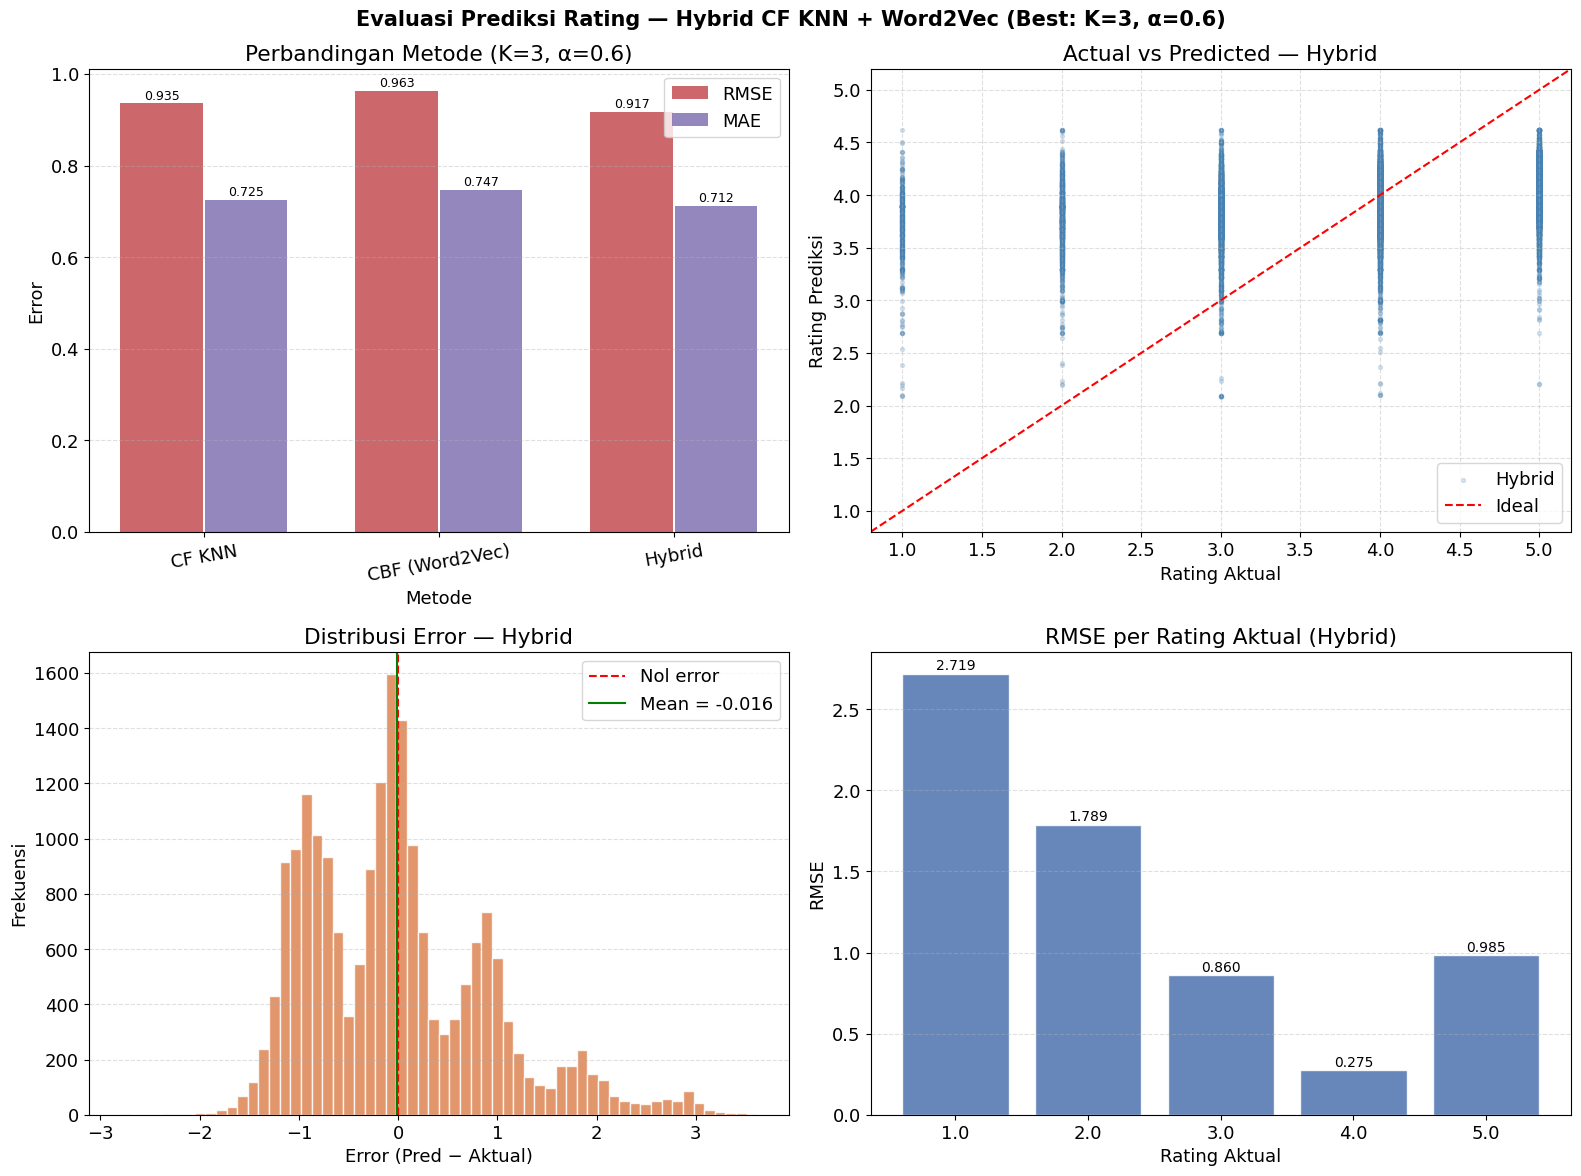

 Disimpan: prediksi_rating_cf_hybrid_best.png


In [25]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle(
    f'Evaluasi Prediksi Rating — Hybrid CF KNN + Word2Vec (Best: K={best_k}, α={best_alpha})',
    fontsize=15, fontweight='bold'
)

# — Plot 1: RMSE & MAE per Metode —
ax        = axes[0, 0]
methods   = ['CF KNN', 'CBF (Word2Vec)', 'Hybrid']
rmse_vals = [rmse_knn, rmse_cbf, rmse_hybrid]
mae_vals  = [mae_knn,  mae_cbf,  mae_hybrid]
x         = np.arange(len(methods))

bars_rmse = ax.bar(x - 0.18, rmse_vals, 0.35, label='RMSE', color='#C44E52', alpha=0.85)
bars_mae  = ax.bar(x + 0.18, mae_vals,  0.35, label='MAE',  color='#8172B2', alpha=0.85)
for bar, v in list(zip(bars_rmse, rmse_vals)) + list(zip(bars_mae, mae_vals)):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.003,
            f'{v:.3f}', ha='center', va='bottom', fontsize=9)
ax.set(title=f'Perbandingan Metode (K={best_k}, α={best_alpha})',
       xlabel='Metode', ylabel='Error')
ax.set_xticks(x)
ax.set_xticklabels(methods, rotation=10)
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.4)

# — Plot 2: Scatter Actual vs Predicted —
ax    = axes[0, 1]
r_min = float(actuals_best.min()) - 0.2
r_max = float(actuals_best.max()) + 0.2
ax.scatter(actuals_best, preds_hybrid, alpha=0.2, s=8, color='steelblue', label='Hybrid')
ax.plot([r_min, r_max], [r_min, r_max], 'r--', linewidth=1.5, label='Ideal')
ax.set(title='Actual vs Predicted — Hybrid',
       xlabel='Rating Aktual', ylabel='Rating Prediksi',
       xlim=[r_min, r_max], ylim=[r_min, r_max])
ax.legend()
ax.grid(True, linestyle='--', alpha=0.4)

# — Plot 3: Distribusi Error —
ax     = axes[1, 0]
errors = preds_hybrid - actuals_best
ax.hist(errors, bins=60, color='#DD8452', edgecolor='white', alpha=0.85)
ax.axvline(0,             color='red',   linestyle='--', linewidth=1.5, label='Nol error')
ax.axvline(errors.mean(), color='green', linestyle='-',  linewidth=1.5,
           label=f'Mean = {errors.mean():.3f}')
ax.set(title='Distribusi Error — Hybrid',
       xlabel='Error (Pred − Aktual)', ylabel='Frekuensi')
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.4)

# — Plot 4: RMSE per Rating Aktual —
ax   = axes[1, 1]
bars = ax.bar([str(r) for r in breakdown.index], breakdown['RMSE'],
              color='#4C72B0', edgecolor='white', alpha=0.85)
for bar, v in zip(bars, breakdown['RMSE']):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
            f'{v:.3f}', ha='center', va='bottom', fontsize=10)
ax.set(title='RMSE per Rating Aktual (Hybrid)',
       xlabel='Rating Aktual', ylabel='RMSE')
ax.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig('data/prediksi_rating_cf_hybrid_best.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Disimpan: prediksi_rating_cf_hybrid_best.png")

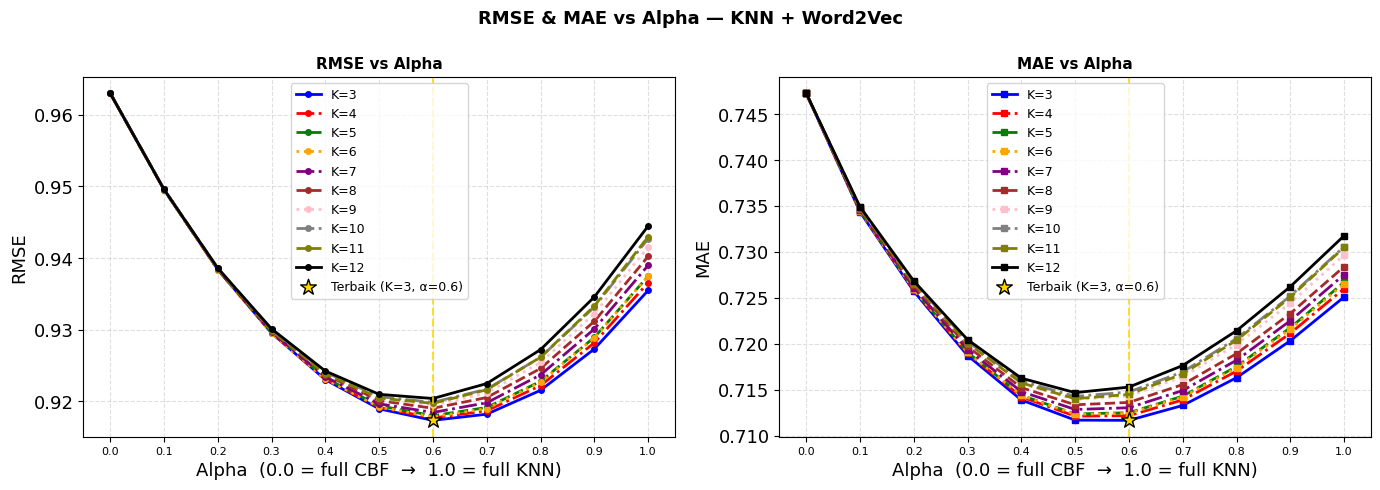

 Disimpan: plot_line_cf_rmse_mae_vs_alpha.png


In [26]:
# ── Plot Line: RMSE & MAE vs Alpha per K ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('RMSE & MAE vs Alpha — KNN + Word2Vec',
             fontsize=13, fontweight='bold')

for ax, pivot, metric_name, marker in [
    (axes[0], pivot_rmse, 'RMSE', 'o'),
    (axes[1], pivot_mae,  'MAE',  's'),
]:
    for k in K_LIST:
        vals = pivot.loc[k].values
        ax.plot(ALPHA_LIST, vals,
                linestyle=K_DASHES[k], color=K_COLORS[k],
                linewidth=2, marker=marker, markersize=4, label=f'K={k}')

    best_val = (pivot_rmse.loc[best_k, best_alpha]
                if metric_name == 'RMSE'
                else pivot_mae.loc[best_k, best_alpha])
    ax.axvline(best_alpha, color='gold', linewidth=1.5, linestyle='--', alpha=0.8)
    ax.scatter([best_alpha], [best_val], color='gold', s=140, zorder=6, marker='*',
               edgecolors='black', label=f'Terbaik (K={best_k}, α={best_alpha})')

    ax.set_title(f'{metric_name} vs Alpha', fontsize=11, fontweight='bold')
    ax.set_xlabel('Alpha  (0.0 = full CBF  →  1.0 = full KNN)')
    ax.set_ylabel(metric_name)
    ax.legend(fontsize=9)
    ax.grid(True, linestyle='--', alpha=0.4)
    ax.set_xticks(ALPHA_LIST)
    ax.set_xticklabels([f'{a:.1f}' for a in ALPHA_LIST], fontsize=8)

plt.tight_layout()
plt.savefig('data/plot_line_cf_rmse_mae_vs_alpha.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Disimpan: plot_line_cf_rmse_mae_vs_alpha.png")

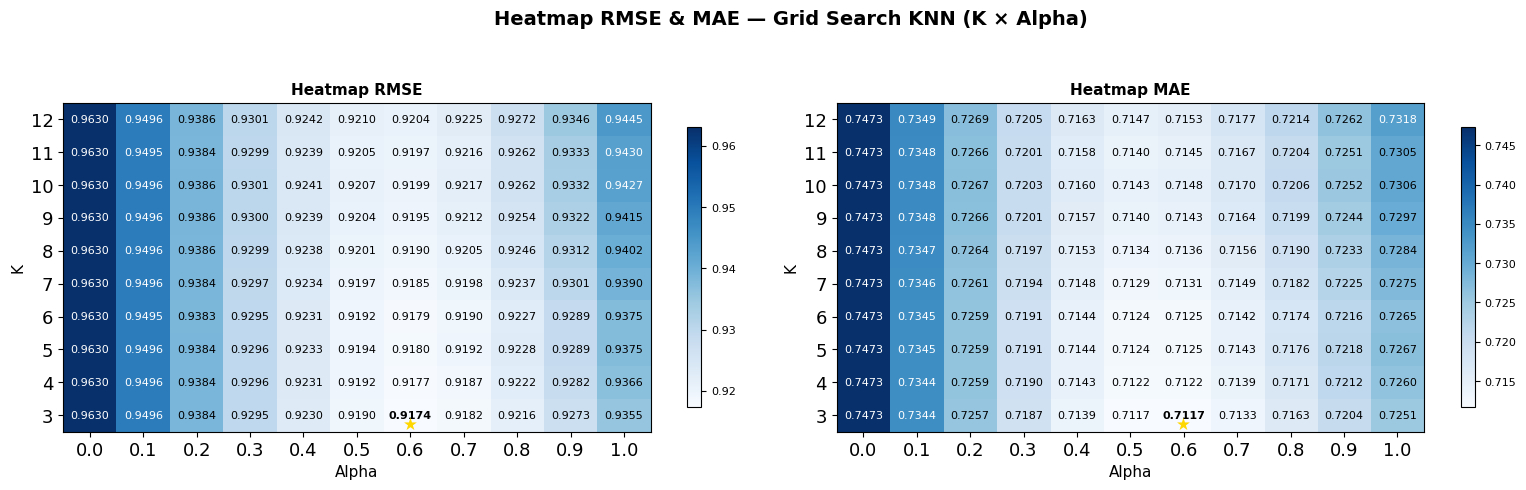

Berhasil disimpan di: d:\Polinema\Skripsi\Skripsi_Sistem_Rekomendasi_Hotel\data\plot_heatmap_knn_rmse_mae.png


In [27]:
import os
import matplotlib.pyplot as plt

# Pastikan folder output ada
os.makedirs("data", exist_ok=True)

# ── Heatmap RMSE & MAE ───────────────────────────────────────
fig2, axes2 = plt.subplots(1, 2, figsize=(16, 5))

fig2.suptitle(
    "Heatmap RMSE & MAE — Grid Search KNN (K × Alpha)",
    fontsize=14,
    fontweight="bold"
)

for ax, pivot, metric_name in [
    (axes2[0], pivot_rmse, "RMSE"),
    (axes2[1], pivot_mae, "MAE"),
]:

    # Heatmap
    im = ax.imshow(
        pivot.values,
        cmap="Blues",
        aspect="auto",
        origin="lower"
    )

    # Colorbar
    cbar = plt.colorbar(im, ax=ax, shrink=0.85)
    cbar.ax.tick_params(labelsize=8)

    # Tick
    ax.set_xticks(range(len(ALPHA_LIST)))
    ax.set_xticklabels([f"{a:.1f}" for a in ALPHA_LIST])

    ax.set_yticks(range(len(K_LIST)))
    ax.set_yticklabels([str(k) for k in K_LIST])

    ax.set_xlabel("Alpha", fontsize=11)
    ax.set_ylabel("K", fontsize=11)

    ax.set_title(
        f"Heatmap {metric_name}",
        fontsize=11,
        fontweight="bold"
    )

    # Nilai minimum & maksimum
    vmin = pivot.values.min()
    vmax = pivot.values.max()

    # Isi setiap sel
    for i, k in enumerate(K_LIST):
        for j, a in enumerate(ALPHA_LIST):

            value = pivot.loc[k, a]

            norm = (value - vmin) / (vmax - vmin + 1e-12)
            text_color = "white" if norm > 0.55 else "black"

            best = (k == best_k) and (abs(a - best_alpha) < 1e-9)

            # Tampilkan nilai
            ax.text(
                j,
                i,
                f"{value:.4f}",
                ha="center",
                va="center",
                fontsize=8,
                color=text_color,
                fontweight="bold" if best else "normal",
            )

            # Tambahkan bintang untuk parameter terbaik
            if best:
                ax.text(
                    j,
                    i - 0.28,      # sedikit di atas angka
                    "★",
                    ha="center",
                    va="center",
                    fontsize=12,
                    color="gold",
                    fontweight="bold",
                )

# Layout
plt.tight_layout(rect=[0, 0, 1, 0.95])

# Simpan
output_path = "data/plot_heatmap_knn_rmse_mae.png"
plt.savefig(output_path, dpi=300, bbox_inches="tight")

# Tampilkan
plt.show()

print(f"Berhasil disimpan di: {os.path.abspath(output_path)}")

## Simpan Hasil ke CSV

In [28]:
df_grid.sort_values('RMSE').reset_index(drop=True).to_csv(
    'data/hasil_grid_search_K_alpha.csv', index=False
)
print(" Tersimpan: data/hasil_grid_search_K_alpha.csv")

df_eval_out = df_eval.copy()
df_eval_out.insert(0, 'user_id',  test_df['user_id'].values)
df_eval_out.insert(1, 'hotel_id', test_df['hotel_id'].values)
df_eval_out['abs_error'] = df_eval_out['error'].abs().round(4)
for col in ['predicted', 'pred_knn', 'pred_cbf']:
    df_eval_out[col] = df_eval_out[col].round(4)

# Urutkan berdasarkan error terkecil
# df_eval_out = df_eval_out.sort_values(
#     by='abs_error',
#     ascending=True
# ).reset_index(drop=True)

df_eval_out.to_csv('data/hasil_prediksi_hybrid_best.csv', index=False)
print(" Tersimpan: data/hasil_prediksi_hybrid_best.csv")

print(f"\nRingkasan Akhir — Best K={best_k}, α={best_alpha}")
print(f"{'Metode':<20} {'RMSE':>8} {'MAE':>8}")
print(f"{'-'*38}")
print(f"{'CF KNN':<20} {rmse_knn:>8.4f} {mae_knn:>8.4f}")
print(f"{'CBF (Word2Vec)':<20} {rmse_cbf:>8.4f} {mae_cbf:>8.4f}")
print(f"{'Hybrid':<20} {rmse_hybrid:>8.4f} {mae_hybrid:>8.4f}")
display(df_eval_out.head(10))

 Tersimpan: data/hasil_grid_search_K_alpha.csv
 Tersimpan: data/hasil_prediksi_hybrid_best.csv

Ringkasan Akhir — Best K=3, α=0.6
Metode                   RMSE      MAE
--------------------------------------
CF KNN                 0.9355   0.7251
CBF (Word2Vec)         0.9630   0.7473
Hybrid                 0.9174   0.7117


,user_id,hotel_id,actual,predicted,error,pred_knn,pred_cbf,strategy,abs_error
0,FB1032DECE1162CB3556D05F278AAFFD,114575,2.0,4.0908,2.090799,4.3333,3.7270,hybrid(α=0.6)_knn_fallback,2.0908
1,FB1032DECE1162CB3556D05F278AAFFD,573340,4.0,4.0782,0.078241,4.3153,3.7226,hybrid(α=0.6)_knn_fallback,0.0782
2,BA524A238B1171206691A6CC3F28F266,108408,3.0,4.0959,1.095891,4.1250,4.0522,hybrid(α=0.6)_knn_fallback,1.0959
3,BA524A238B1171206691A6CC3F28F266,93430,3.0,3.9113,0.911315,3.8172,4.0525,hybrid(α=0.6)_knn_fallback,0.9113
4,BA524A238B1171206691A6CC3F28F266,87620,4.0,3.9897,-0.010318,3.9474,4.0532,hybrid(α=0.6)_knn_fallback,0.0103
5,EC6CB11E9DC8761710DDA3CF48DD995F,2322597,5.0,4.5770,-0.423027,4.9286,4.0496,hybrid(α=0.6)_knn_fallback,0.4230
6,C81AB7D49D98FA410EA191E15F427BEC,111501,1.0,3.8787,2.878671,3.7636,4.0512,hybrid(α=0.6)_knn_fallback,2.8787
7,C81AB7D49D98FA410EA191E15F427BEC,80668,5.0,4.2209,-0.779121,4.3333,4.0522,hybrid(α=0.6)_knn_fallback,0.7791
8,2404E3630B78BB9E8D6583076FBA0742,100613,4.0,3.8189,-0.181130,3.6667,4.0472,hybrid(α=0.6)_knn_fallback,0.1811
9,2404E3630B78BB9E8D6583076FBA0742,1485961,4.0,4.3585,0.358511,4.5625,4.0525,hybrid(α=0.6)_knn_fallback,0.3585


In [29]:
# ── Tabel Perbandingan Model: KNN vs Word2Vec (CBF) vs Hybrid ──
df_perbandingan = pd.DataFrame({
    'Model'      : ['Collaborative Filtering (KNN)', 'Content-Based Filtering (Word2Vec)', 'Hybrid'],
    'RMSE'  : [rmse_knn, rmse_cbf, rmse_hybrid],
    'MAE'   : [mae_knn, mae_cbf, mae_hybrid],
})

df_perbandingan[['RMSE', 'MAE']] = df_perbandingan[['RMSE', 'MAE']].round(4)

df_perbandingan.to_csv('data/hasil_perbandingan_model.csv', index=False)
print(" Tersimpan: data/hasil_perbandingan_model.csv")
display(df_perbandingan)

 Tersimpan: data/hasil_perbandingan_model.csv


,Model,RMSE,MAE
0,Collaborative Filtering (KNN),0.9355,0.7251
1,Content-Based Filtering (Word2Vec),0.9630,0.7473
2,Hybrid,0.9174,0.7117
